In [170]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# Data Load

In [171]:
df_sample = pd.read_csv("sample_submission.csv")
df_test = pd.read_csv("test.csv")
df_train = pd.read_csv("train.csv")
print(f"Train data shape: {df_train.shape}, Test data shape: {df_test.shape}, Sample submission data shape: {df_sample.shape}")
df_train.head()

Train data shape: (439140, 16), Test data shape: (188165, 15), Sample submission data shape: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [172]:
df_test.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


# Data Description

* id: record id
* Driver: Driver code
* Compound: Tire compound
* Race: Grand Prix name
* Year: Season of the race
* PitStop:  Whether the driver pitted on that lap (0/1)
* LapNumber: Lap index within the race
* Stint: Tire stint number
* TyreLife: Number of laps on current tire
* Position: Driver’s position on that lap
* LapTime (s): Lap time in seconds
* LapTime_Delta: Change in lap time from previous lap
* Cumulative_Degradation: Accumulated tire performance drop
* RaceProgress: Fraction of race completed (0 → 1)
* Position_Change: Position gain/loss compared to previous lap
* PitNextLap: Target variable: whether the driver will pit next lap (0/1)

# EDA

In [173]:
nacount_train = df_train.isna().sum()
nacount_test = df_test.isna().sum()
print(f"Train NA counts: {nacount_train[nacount_train > 0]}, Test NA counts: {nacount_test[nacount_test > 0]}")


Train NA counts: Series([], dtype: int64), Test NA counts: Series([], dtype: int64)


In [174]:
df_train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


**Observations:**
- There seems to be no missing values
- There is clear outlier in Laptime (s), LapTime_Delta, Cumulative_Degradation
- There is probable outlier in TyreLife and Position change

In [175]:
df_test.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000
mean,533222.000000,2023.528440,0.136263,23.050185,1.784237,14.160625,9.604539,90.986869,-3.577802,-25.849491,0.336695,0.106800
std,54318.701038,1.025376,0.343069,17.002292,0.948800,9.852778,5.273444,20.855248,40.348466,54.920269,0.253396,4.020592
min,439140.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.017000,-2403.216000,-274.564000,0.012821,-18.000000
25%,486181.000000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.634000,-8.874000,-46.814000,0.128205,-1.000000
50%,533222.000000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.485000,-0.285000,-21.027000,0.269231,0.000000
75%,580263.000000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.485000,0.122000,-6.188000,0.512821,2.000000
max,627304.000000,2025.000000,1.000000,77.000000,8.000000,77.000000,20.000000,2497.905000,2433.472000,2406.800000,1.000000,18.000000


In [176]:
print(f" Train data- Drivers: {df_train['Driver'].nunique()}, Compounds: {df_train['Compound'].nunique()}, Race: {df_train['Race'].nunique()}")
print(f" Test data- Drivers: {df_test['Driver'].nunique()}, Compounds: {df_test['Compound'].nunique()}, Race: {df_test['Race'].nunique()}")

 Train data- Drivers: 887, Compounds: 5, Race: 26
 Test data- Drivers: 801, Compounds: 5, Race: 26


In [177]:
# Analyze the distribution of tire compounds
df_temp = (
    df_train['Compound']
    .value_counts()
    .reset_index()
)
df_temp['Percentage'] = df_temp['count'] / df_temp['count'].sum() * 100
df_temp.head(10)

,Compound,count,Percentage
0,MEDIUM,211141,48.080567
1,HARD,170518,38.829986
2,SOFT,38744,8.822699
3,INTERMEDIATE,17382,3.958191
4,WET,1355,0.308558


In [178]:
# Analyze the distribution of lap times
df_train['LapTime (s)'].describe(), df_train['LapTime (s)'].quantile([ 0.9, 0.99])

(count    439140.000000
 mean         90.948735
 std          19.772769
 min          67.694000
 25%          82.621000
 50%          90.521000
 75%          98.471000
 max        2507.607000
 Name: LapTime (s), dtype: float64,
 0.90    103.69
 0.99    124.90
 Name: LapTime (s), dtype: float64)

In [179]:
# Fixing the outliers in LapTime (s) by capping at 200 seconds
df_train['Laptime_bin'] = pd.cut(
    df_train['LapTime (s)'], 
    bins=[60, 80, 90, 100, 125,  np.inf], 
    labels=['60-80', '80-90', '90-100', '100-125', '125+']
)
df_lap_bin = df_train.groupby('Laptime_bin').agg({'LapTime (s)': ['count', 'mean', 'min', 'median', 'max']}).reset_index()
df_lap_bin

Laptime_bin LapTime (s)                                         
                    count        mean      min    median       max
0       60-80       78090   75.978525   67.694   76.8560    80.000
1       80-90      137879   84.655161   80.003   84.5100    90.000
2      90-100      147205   95.646133   90.001   95.7660   100.000
3     100-125       71644  106.308498  100.001  104.6970   124.996
4        125+        4322  147.603031  125.011  134.9745  2507.607

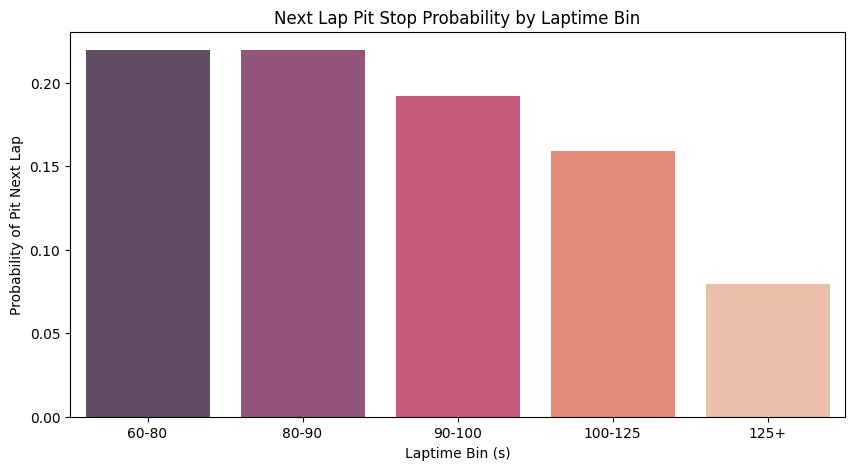

In [180]:
df_laptime = df_train.groupby('Laptime_bin')['PitNextLap'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Laptime_bin', y='PitNextLap', data=df_laptime, palette='rocket', alpha=0.8)
plt.title('Next Lap Pit Stop Probability by Laptime Bin')
plt.xlabel('Laptime Bin (s)')
plt.ylabel('Probability of Pit Next Lap')
plt.show()

**Observations:**
- The probability of pitting on the next lap decreases as lap time increases, suggesting drivers are more likely to pit immediately after recording relatively fast laps rather than very slow laps.

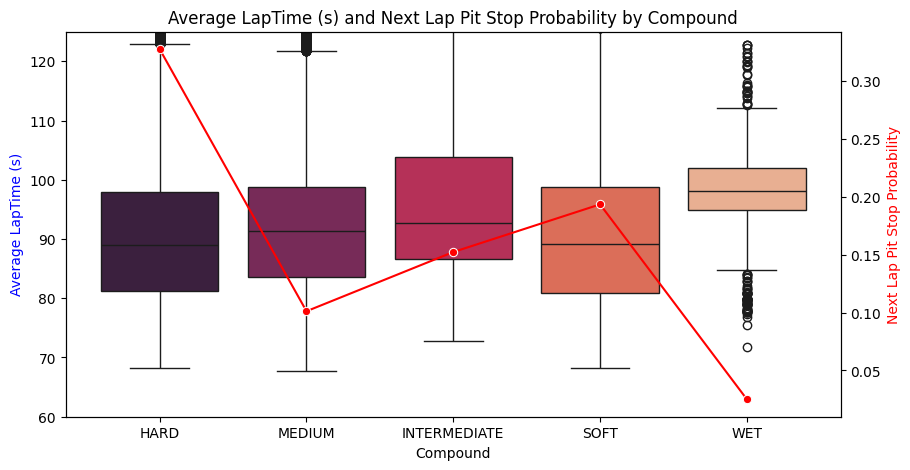

In [181]:
df_comp = (df_train.groupby('Compound').agg({
    'LapTime (s)': 'median', 'PitStop': 'mean', 'PitNextLap': 'mean', 'TyreLife': 'mean', 'LapTime_Delta': 'median', 'Cumulative_Degradation': 'median'
}).reset_index())
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_train, x='Compound', y='LapTime (s)', ax=ax1, palette='rocket')
ax1.set_ylim(60, 125)
ax1.set_ylabel('Average LapTime (s)', color='blue')

ax2 = ax1.twinx()
sns.lineplot(data=df_comp, x='Compound', y='PitNextLap', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Next Lap Pit Stop Probability', color='red')
plt.title('Average LapTime (s) and Next Lap Pit Stop Probability by Compound')
plt.show()

**Observations:**
- Hard tires produces lowest laptime and highest next-lap pit stop probability whereas wet tires produces higher laptime and lowest pit stop probability compartively

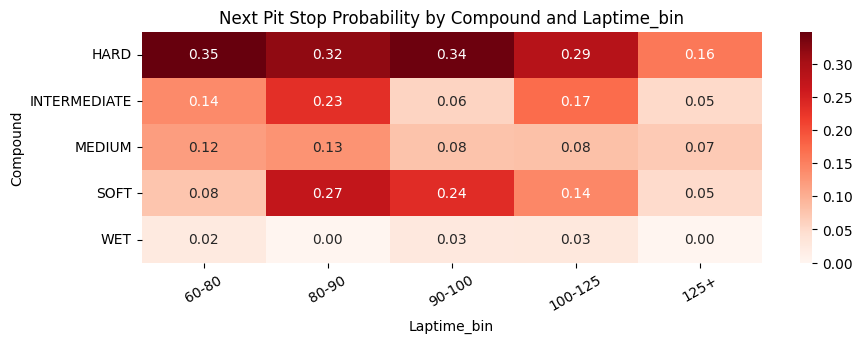

In [182]:
df_pivot = df_train.pivot_table(values='PitNextLap', index='Compound', 
                             columns='Laptime_bin', aggfunc='mean')

plt.figure(figsize=(10, 3))
sns.heatmap(df_pivot, annot=True, cmap='Reds', fmt=".2f")
plt.title('Next Pit Stop Probability by Compound and Laptime_bin')
plt.xticks(rotation=30, ha='center')
plt.show()

**Observation**
- The relationship between lap time and pit probability varies by compound, with Hard tires showing elevated pit probabilities across multiple lap-time bins while Wet tires exhibit consistently low pit probabilities regardless of lap time

In [183]:
# Analyze the distribution of lap time delta
df_train['LapTime_Delta'].describe(), df_train['LapTime_Delta'].quantile([0.01,0.1, 0.9, 0.99])

(count    439140.000000
 mean         -3.770040
 std          43.945759
 min       -2403.895000
 25%          -8.884000
 50%          -0.295000
 75%           0.115000
 max        2423.932000
 Name: LapTime_Delta, dtype: float64,
 0.01   -40.25688
 0.10   -17.43300
 0.90     9.73000
 0.99    30.93200
 Name: LapTime_Delta, dtype: float64)

In [184]:
df_train['LapTime_Delta_bin'] = pd.cut(
    df_train['LapTime_Delta'], 
    bins=[-np.inf,-50, -20, -10,-1, 1, 10, 30, np.inf], 
    labels=['<-50', '-50--20', '-20--10', '-10--1', '-1-1', '1-10', '10-30', '30+']
)

df_lap_del_bin = df_train.groupby('LapTime_Delta_bin').agg({'LapTime_Delta': ['count', 'mean', 'min', 'median', 'max']}).reset_index()
df_lap_del_bin

LapTime_Delta_bin LapTime_Delta                                        
                            count        mean       min  median       max
0              <-50          1443 -263.277024 -2403.895 -55.659   -50.011
1           -50--20         29531  -30.492136   -49.996 -30.644   -20.000
2           -20--10         64441  -14.463997   -19.999 -14.529   -10.000
3            -10--1         99720   -5.597022    -9.999  -5.680    -1.000
4              -1-1        157238   -0.079688    -0.999  -0.042     1.000
5              1-10         44725    5.141471     1.001   4.817    10.000
6             10-30         37126   18.511000    10.003  17.944    29.998
7               30+          4916   42.787658    30.006  34.554  2423.932

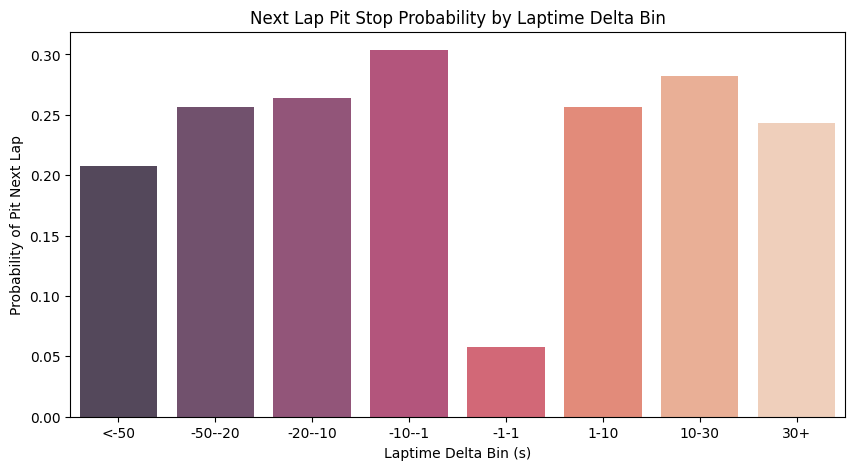

In [185]:
df_laptimedel = df_train.groupby('LapTime_Delta_bin')['PitNextLap'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='LapTime_Delta_bin', y='PitNextLap', data=df_laptimedel, palette='rocket', alpha=0.8)
plt.title('Next Lap Pit Stop Probability by Laptime Delta Bin')
plt.xlabel('Laptime Delta Bin (s)')
plt.ylabel('Probability of Pit Next Lap')
plt.show()

**Observations:**
- 

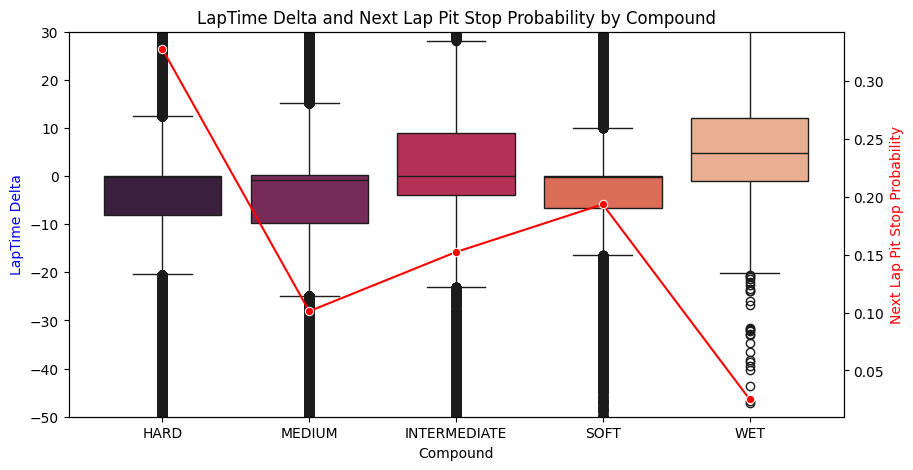

In [186]:
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_train, x='Compound', y='LapTime_Delta', ax=ax1, palette='rocket')
ax1.set_ylim(-50, 30)
ax1.set_ylabel('LapTime Delta', color='blue')

ax2 = ax1.twinx()
sns.lineplot(data=df_comp, x='Compound', y='PitNextLap', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Next Lap Pit Stop Probability', color='red')
plt.title('LapTime Delta and Next Lap Pit Stop Probability by Compound')
plt.show()

**Observations:**
- Hard tires have the highest next-lap pit probability despite similar lap-time delta distributions to other compounds, indicating compound-specific strategy influences pit decisions beyond lap-time changes.

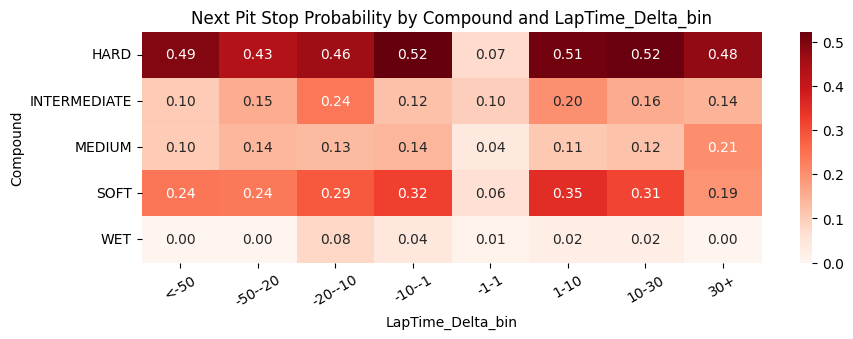

In [187]:
df_pivot = df_train.pivot_table(values='PitNextLap', index='Compound', 
                             columns='LapTime_Delta_bin', aggfunc='mean')

plt.figure(figsize=(10, 3))
sns.heatmap(df_pivot, annot=True, cmap='Reds', fmt=".2f")
plt.title('Next Pit Stop Probability by Compound and LapTime_Delta_bin')
plt.xticks(rotation=30, ha='center')
plt.show()

**Observations:**
- Pit-stop probability is lowest when lap-time delta is near zero (-1 to 1 seconds) and increases when lap-time changes are strongly positive or negative, suggesting unusual performance changes often precede pit stops.

In [188]:
# Analyze the distribution of lap time delta
df_train['Cumulative_Degradation'].describe(), df_train['Cumulative_Degradation'].quantile([0.01, 0.1, 0.8 ,0.9, 0.99])

(count    439140.000000
 mean        -25.721759
 std          54.766573
 min        -274.564000
 25%         -46.566250
 50%         -20.994000
 75%          -6.199000
 max        2412.026000
 Name: Cumulative_Degradation, dtype: float64,
 0.01   -205.034
 0.10    -75.748
 0.80     -3.900
 0.90     10.491
 0.99    122.154
 Name: Cumulative_Degradation, dtype: float64)

In [189]:
df_train['Cumulative_Degradation_bin'] = pd.cut(
    df_train['Cumulative_Degradation'], 
    bins=[-np.inf, -200, -75, -50,-20, -5, 10, 120, np.inf], 
    labels=['<-200', '-200--75', '-75--50', '-50--20', '-20--5', '-5-10', '10-120', '120+']
)

df_cum_deg_bin = df_train.groupby('Cumulative_Degradation_bin').agg({'Cumulative_Degradation': ['count', 'mean', 'min', 'median', 'max']}).reset_index()
df_cum_deg_bin

Cumulative_Degradation_bin Cumulative_Degradation                       \
                                              count        mean      min   
0                      <-200                   6116 -217.887189 -274.564   
1                   -200--75                  38535 -111.953602 -200.000   
2                    -75--50                  52886  -59.535250  -74.988   
3                    -50--20                 135454  -32.633758  -49.997   
4                     -20--5                 106134  -12.461907  -19.999   
5                      -5-10                  55758   -1.267637   -4.998   
6                     10-120                  39095   66.302650   10.000   
7                       120+                   5162  139.760179  120.003   

                      
    median       max  
0 -212.854  -200.003  
1  -96.182   -75.000  
2  -58.009   -50.000  
3  -32.039   -20.000  
4  -11.868    -5.000  
5   -1.832     9.995  
6   77.987   119.992  
7  130.477  2412.026

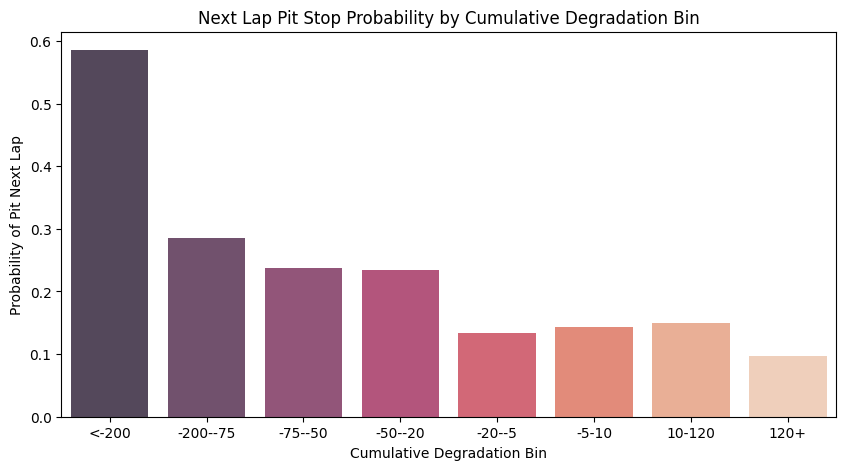

In [190]:
df_laptimedel = df_train.groupby('Cumulative_Degradation_bin')['PitNextLap'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Cumulative_Degradation_bin', y='PitNextLap', data=df_laptimedel, palette='rocket', alpha=0.8)
plt.title('Next Lap Pit Stop Probability by Cumulative Degradation Bin')
plt.xlabel('Cumulative Degradation Bin')

plt.ylabel('Probability of Pit Next Lap')
plt.show()

**Observations:**
- Pit-stop probability is highest for extremely negative cumulative degradation values (< -200) and generally decreases as cumulative degradation approaches normal ranges.

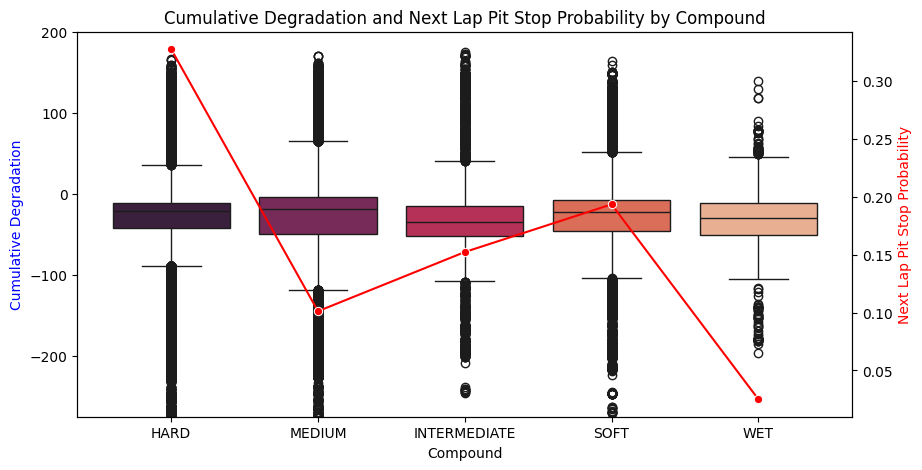

In [191]:
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_train, x='Compound', y='Cumulative_Degradation', ax=ax1, palette='rocket')
ax1.set_ylim(df_train['Cumulative_Degradation'].min(), 200)
ax1.set_ylabel('Cumulative Degradation', color='blue')
ax2 = ax1.twinx()
sns.lineplot(data=df_comp, x='Compound', y='PitNextLap', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Next Lap Pit Stop Probability', color='red')
plt.title('Cumulative Degradation and Next Lap Pit Stop Probability by Compound')
plt.show()

**Observations:**
- Hard tires exhibit the highest next-lap pit probability even though cumulative degradation distributions overlap considerably across compounds.

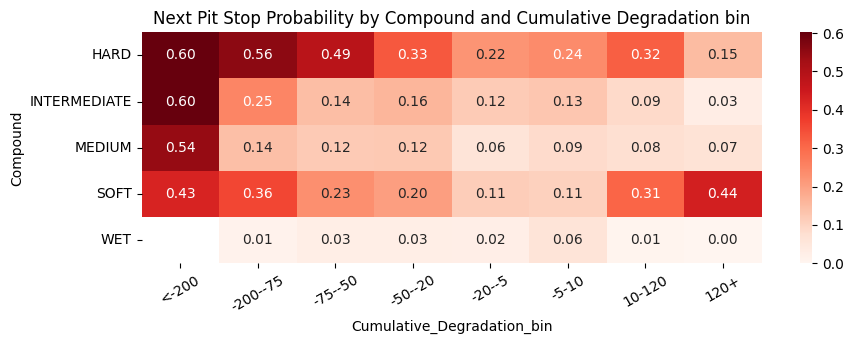

In [192]:
df_pivot = df_train.pivot_table(values='PitNextLap', index='Compound', 
                             columns='Cumulative_Degradation_bin', aggfunc='mean')

plt.figure(figsize=(10, 3))
sns.heatmap(df_pivot, annot=True, cmap='Reds', fmt=".2f")
plt.title('Next Pit Stop Probability by Compound and Cumulative Degradation bin')
plt.xticks(rotation=30, ha='center')
plt.show()

**Observations:**
- For Hard, Medium, and Intermediate compounds, pit-stop probability is highest under extreme degradation conditions and generally declines as degradation becomes less severe.

In [193]:
df_train['TyreLife'].describe(), df_train['TyreLife'].quantile([0.9, 0.95, 0.99])

(count    439140.000000
 mean         14.158231
 std           9.801338
 min           1.000000
 25%           6.000000
 50%          12.000000
 75%          20.000000
 max          77.000000
 Name: TyreLife, dtype: float64,
 0.90    27.0
 0.95    32.0
 0.99    43.0
 Name: TyreLife, dtype: float64)

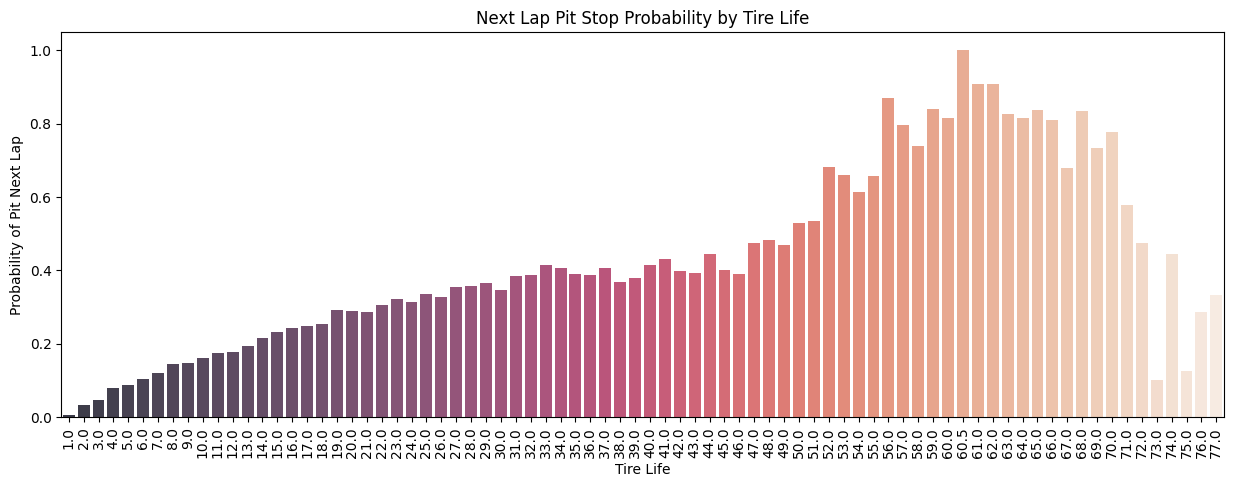

In [194]:
df_tyr = df_train.groupby('TyreLife')['PitNextLap'].mean().reset_index()
plt.figure(figsize=(15, 5))
sns.barplot(x='TyreLife', y='PitNextLap', data=df_tyr, palette='rocket', alpha=0.8)
plt.title('Next Lap Pit Stop Probability by Tire Life')
plt.xlabel('Tire Life')
plt.xticks(rotation=90, ha='center')

plt.ylabel('Probability of Pit Next Lap')
plt.show()

**Observations:**
- Pit-stop probability increases steadily with tire age, peaking around 55–65 laps, indicating tire life is one of the strongest predictors of an upcoming pit stop.

In [195]:
df_train['TyreLife_bin'] = pd.cut(
    df_train['TyreLife'], 
    bins=[0, 5, 10, 20, 25, 50, 70, np.inf], 
    labels=['0-5', '5-10', '10-20', '20-25', '25-50', '50-70', '70+']
)

df_tyre_life_bin = df_train.groupby('TyreLife_bin').agg({'TyreLife': ['count', 'mean', 'min', 'median', 'max']}).reset_index()
df_tyre_life_bin

TyreLife_bin TyreLife                              
                  count       mean   min median   max
0          0-5    90638   3.056522   1.0    3.0   5.0
1         5-10    92543   7.932107   6.0    8.0  10.0
2        10-20   153792  15.047109  11.0   15.0  20.0
3        20-25    45310  22.844339  21.0   23.0  25.0
4        25-50    55476  32.021126  26.0   30.0  50.0
5        50-70     1281  57.300156  51.0   56.0  70.0
6          70+      100  73.400000  71.0   74.0  77.0

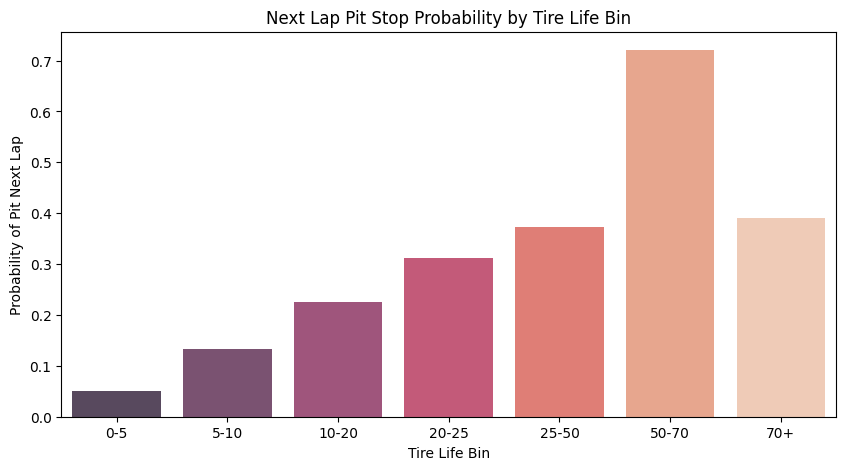

In [196]:
df_tyibin = df_train.groupby('TyreLife_bin')['PitNextLap'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='TyreLife_bin', y='PitNextLap', data=df_tyibin, palette='rocket', alpha=0.8)
plt.title('Next Lap Pit Stop Probability by Tire Life Bin')
plt.xlabel('Tire Life Bin')
plt.ylabel('Probability of Pit Next Lap')
plt.show()

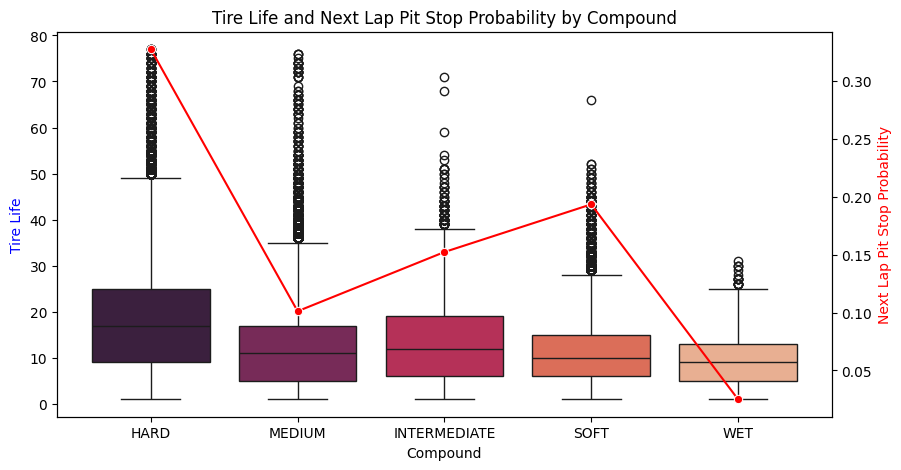

In [197]:
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_train, x='Compound', y='TyreLife', ax=ax1, palette='rocket')

ax1.set_ylabel('Tire Life', color='blue')
ax2 = ax1.twinx()
sns.lineplot(data=df_comp, x='Compound', y='PitNextLap', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Next Lap Pit Stop Probability', color='red')
plt.title('Tire Life and Next Lap Pit Stop Probability by Compound')
plt.show()

**Observations:**
- Hard tires combine the longest tire life with the highest next-lap pit probability, suggesting teams frequently extend hard-tire stints before pitting.

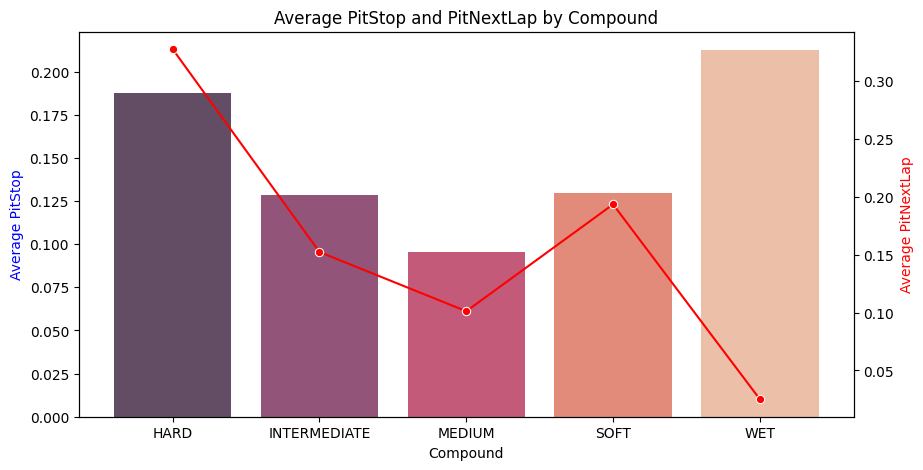

In [198]:

# Analyze the distribution of lap time delta
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_comp, x='Compound', y='PitStop', ax=ax1, palette='rocket', alpha=0.8)
ax1.set_ylabel('Average PitStop', color='blue')

ax2 = ax1.twinx()
sns.lineplot(data=df_comp, x='Compound', y='PitNextLap', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average PitNextLap', color='red')
plt.title('Average PitStop and PitNextLap by Compound')
plt.show()

**Observations:**
- Wet tires have the highest overall pit-stop frequency but the lowest next-lap pit probability, indicating their pit stops are driven more by changing track conditions than gradual tire wear.

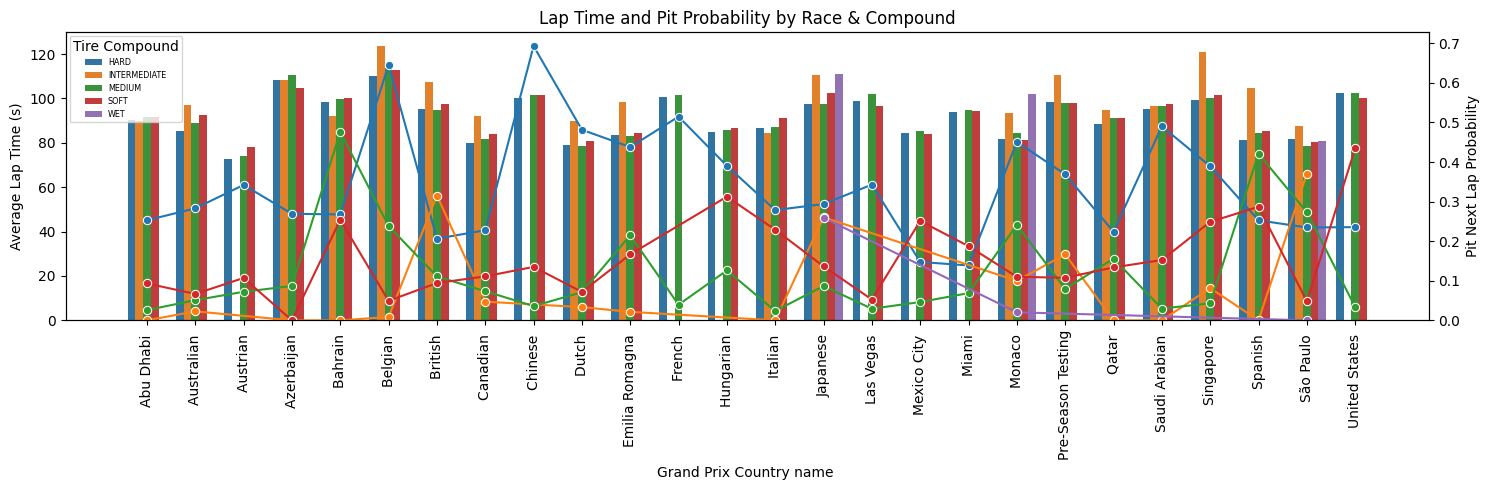

In [199]:
df_comp_rc = df_train.groupby(['Race','Compound'])[['LapTime (s)', 'PitStop', 'PitNextLap']].mean().reset_index()
df_comp_rc['Race_country'] = df_comp_rc['Race'].str.replace('Grand Prix', '', regex=False)

fig, ax1 = plt.subplots(figsize=(15, 5))

sns.barplot(data=df_comp_rc, x='Race_country', y='LapTime (s)', hue='Compound', ax = ax1)
ax1.set_title('Lap Time and Pit Probability by Race & Compound')
ax1.set_ylabel('Average Lap Time (s)')
ax1.set_xlabel("Grand Prix Country name ")
ax1.tick_params(axis='x', rotation=90)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, title='Tire Compound', loc='upper left', fontsize='xx-small',)

ax2 = ax1.twinx()
sns.lineplot(data=df_comp_rc, x='Race_country', y='PitNextLap', ax=ax2, color='red', marker='o', hue='Compound', legend=False)
ax2.set_ylabel('Pit Next Lap Probability')
ax2.set_ylim(0, df_comp_rc['PitNextLap'].max() * 1.05)

plt.tight_layout()
plt.show()

**Observations:**
- Hard and Medium tires are used evrey where, whereas other three component types are missing sometimes
- This chart indicates that laptime is not directly affcet pit stop, eg:
    - Chinese - hard has high pit prob despit lap time being average, 
    - Italian/ Bagrain - intermedate has smallest lap time and also lowest pti stop probability
    - Singapore: High lap times for all compounds, but pit probability varies significantly by compound.

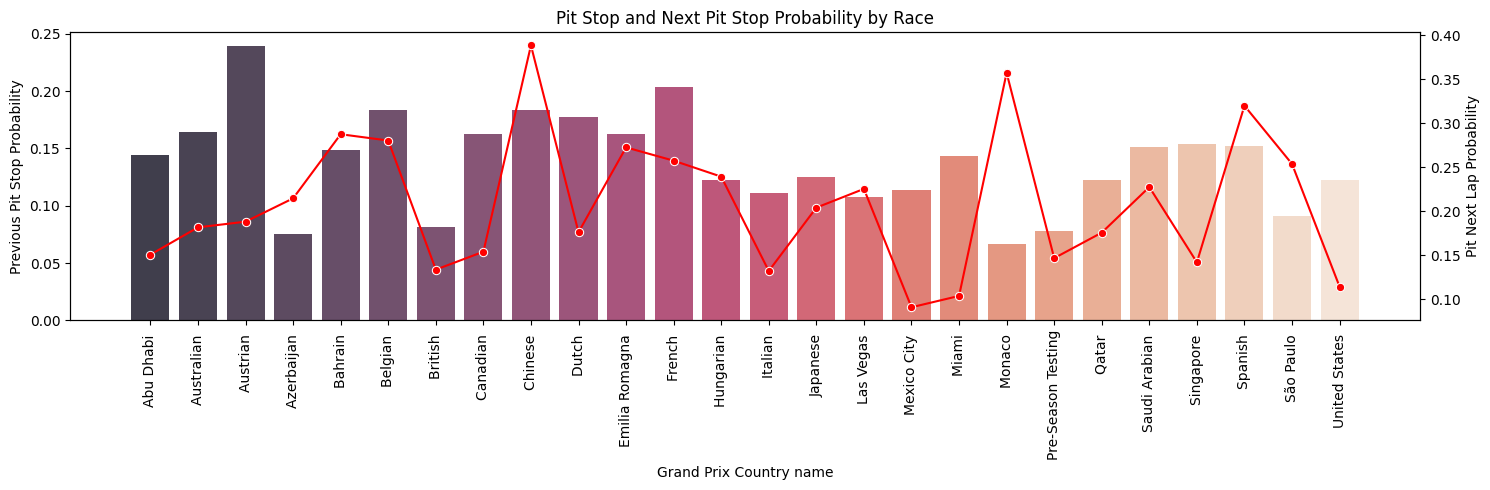

In [200]:
df_race = (df_train.groupby('Race')[['LapTime (s)', 'PitStop', 'PitNextLap', 'TyreLife']].mean().reset_index())
df_race['Race_country'] = df_race['Race'].str.replace('Grand Prix', '', regex=False)

fig, ax1 = plt.subplots(figsize=(15, 5))

sns.barplot(data=df_race, x='Race_country', y='PitStop', ax = ax1, palette='rocket', alpha=0.8)
ax1.set_title('Pit Stop and Next Pit Stop Probability by Race')
ax1.set_ylabel('Previous Pit Stop Probability')
ax1.set_xlabel("Grand Prix Country name")
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
sns.lineplot(data=df_race, x='Race_country', y='PitNextLap', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Pit Next Lap Probability')

plt.tight_layout()
plt.show()

**Observations:**
- Average previous pit-stop and next-lap pit probability do not show a strong positive relationship across races
- Pit-next-lap probability varies more across races than average previous pit-stop.
- This indicates others factors impact the next-lap pit probability than previous pit-stops

In [201]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_train['PitStop'], df_train['PitNextLap']) 
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")
print(f"Cramer's V: {cramers_v:.4f}")
print("\nContingency Table:")
print(contingency_table)

Chi-Square Statistic: 1035.4777
P-value: 0.000000
Degrees of Freedom: 1
Cramer's V: 0.0486

Contingency Table:
PitNextLap     0.0    1.0
PitStop                  
0           306798  72567
1            44961  14814


**Observations**
* P-value < 0.05 means there is PitStop and PitNextLap are not independent
* However, Cramer's V = 0.0486 indicates the association is very weak.

**Observations:**
- Since p<0.05, The differnece in average Tyre life is significant in deciding the next-lap pit stop, which makes sense

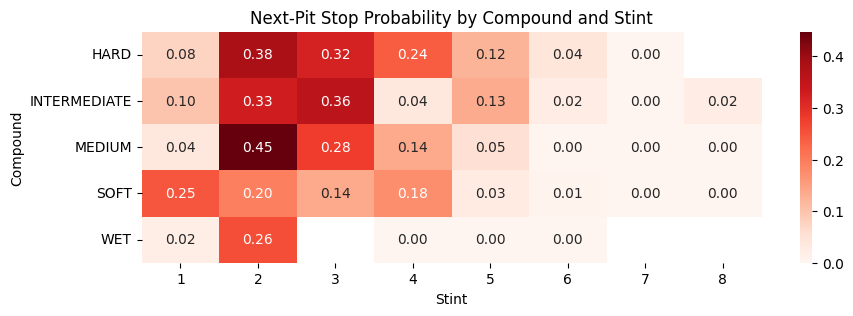

In [202]:
df_pivot = df_train.pivot_table(values='PitNextLap', index='Compound', 
                             columns='Stint', aggfunc='mean')

plt.figure(figsize=(10, 3))
sns.heatmap(df_pivot, annot=True, cmap='Reds', fmt=".2f")
plt.title('Next-Pit Stop Probability by Compound and Stint')
plt.show()

**Observations:**
- Next-pit stop probability peaks during Stint 2 across all compounds and generally decreases in later stints, highlighting stint progression as a key determinant of pit strategy.

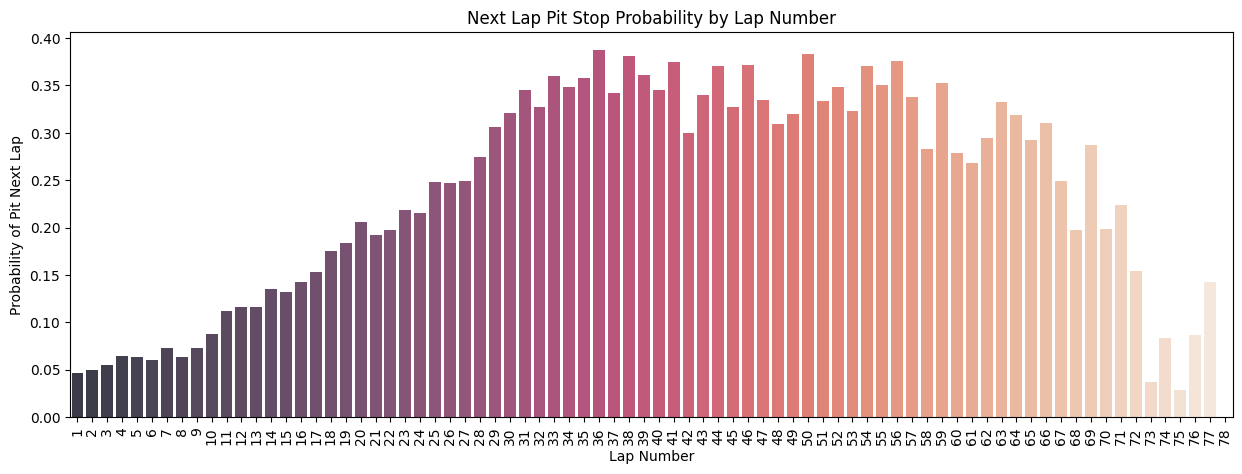

In [203]:
df_lap = df_train.groupby('LapNumber')['PitNextLap'].mean().reset_index()
fig, ax1 = plt.subplots(figsize=(15, 5))
sns.barplot(data=df_lap, x='LapNumber', y='PitNextLap', ax=ax1, palette='rocket', alpha=0.8)
ax1.set_title('Next Lap Pit Stop Probability by Lap Number')
ax1.set_xlabel('Lap Number')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Probability of Pit Next Lap')
plt.show()

**Observations:**
- Pit-stop probability increases throughout the race, peaks around laps 35–60, and then declines toward the final laps as remaining pit opportunities decrease.

In [204]:
print(df_train['LapNumber'].describe(), df_train['LapNumber'].quantile([0.01, 0.1, 0.9, 0.99])) 

count    439140.000000
mean         23.105909
std          16.958261
min           1.000000
25%           9.000000
50%          19.000000
75%          36.000000
max          78.000000
Name: LapNumber, dtype: float64 0.01     1.0
0.10     4.0
0.90    49.0
0.99    66.0
Name: LapNumber, dtype: float64


  LapNumber_Bin LapNumber                          
                    count       mean min max median
0          0-10    127868   5.303399   1  10    5.0
1         10-20    105458  15.059313  11  20   15.0
2         20-30     66616  25.305692  21  30   25.0
3         30-40     54967  35.518766  31  40   36.0
4         40-50     50352  45.418017  41  50   45.0
5         50-60     24033  54.597262  51  60   54.0
6         60-70      9308  64.909540  61  70   65.0
7         70-80       538  72.756506  71  78   72.0


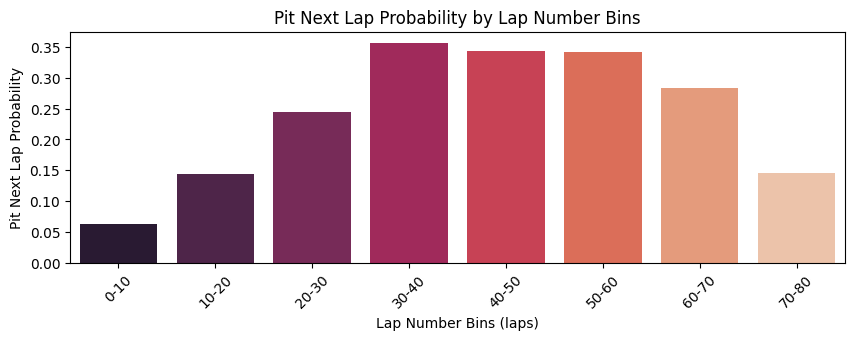

In [205]:
df_train['LapNumber_Bin'] = pd.cut(
    df_train['LapNumber'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
)
print(df_train.groupby('LapNumber_Bin').agg({'LapNumber': ['count', 'mean', 'min', 'max', 'median']}).reset_index())

df_lap_bin = df_train.groupby('LapNumber_Bin')['PitNextLap'].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 3))
sns.barplot(data=df_lap_bin, x='LapNumber_Bin', y='PitNextLap', ax=ax1, palette='rocket')
ax1.set_title('Pit Next Lap Probability by Lap Number Bins')
ax1.set_xlabel('Lap Number Bins (laps)')
ax1.set_ylabel('Pit Next Lap Probability')
plt.xticks(rotation=45)
plt.show()

**Observations:**
- Probability of next-lap pit stop is highest in 30-40 lap number and then gradually decreases towards the end of race

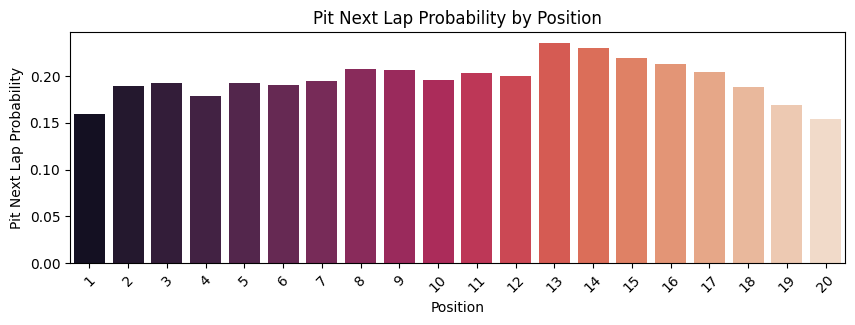

In [206]:

df_pos_bin = df_train.groupby('Position')['PitNextLap'].mean().reset_index()
fig, ax1 = plt.subplots(figsize=(10, 3))
sns.barplot(data=df_pos_bin, x='Position', y='PitNextLap', ax=ax1, palette='rocket')
ax1.set_title('Pit Next Lap Probability by Position')
ax1.set_xlabel('Position')
ax1.set_ylabel('Pit Next Lap Probability')
plt.xticks(rotation=45)
plt.show()

**Observations:**
- Mid-field drivers (positions 13–15) show the highest pit-stop probability, suggesting strategic flexibility is greater in the middle of the field than at the front or rear.

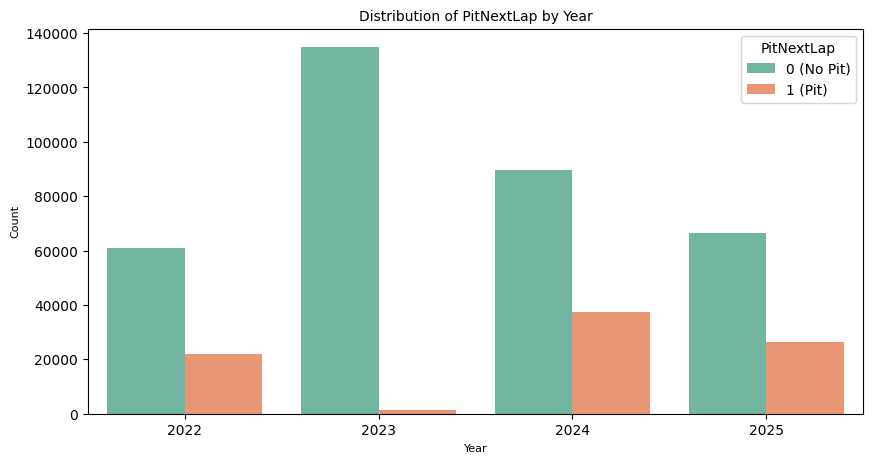

In [207]:
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.countplot(data=df_train, x='Year', hue='PitNextLap', palette='Set2', ax=ax)

plt.title('Distribution of PitNextLap by Year', fontsize=10)
plt.xlabel('Year', fontsize=8)
plt.ylabel('Count', fontsize=8)

plt.legend(title='PitNextLap', labels=['0 (No Pit)', '1 (Pit)'])
plt.show()

**Observations:**
- The frequency of next-lap pit events varies substantially by season, with 2024 and 2025 exhibiting a much higher proportion of pit events than 2023.

In [208]:
df_train_num = df_train.select_dtypes(include=['int', 'float'])
df_train_num.head()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


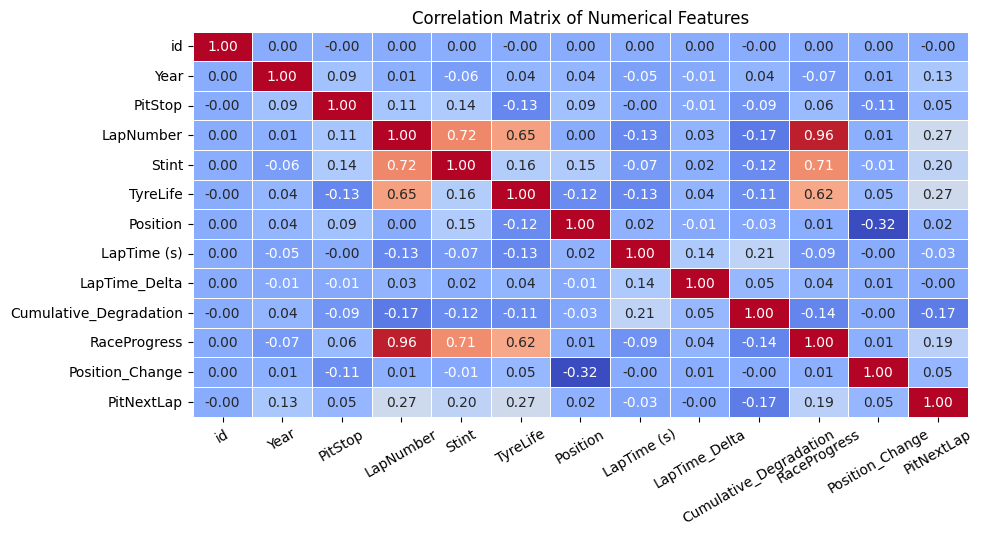

In [209]:
df_cr = df_train_num.corr()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_cr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=False, square=False, ax=ax)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=30, ha='center')
plt.show()

**Observations:**
- TireLife (0.27) and LapNumber (0.27) show the strongest positive correlations with PitNextLap among the available numerical features, while Cumulative_Degradation (-0.17) exhibits the strongest negative relationship.

## Feature Engineering

In [210]:
df_train.dtypes

id                               int64
Driver                          object
Compound                        object
Race                            object
Year                             int64
PitStop                          int64
LapNumber                        int64
Stint                            int64
TyreLife                       float64
Position                         int64
LapTime (s)                    float64
LapTime_Delta                  float64
Cumulative_Degradation         float64
RaceProgress                   float64
Position_Change                float64
PitNextLap                     float64
Laptime_bin                   category
LapTime_Delta_bin             category
Cumulative_Degradation_bin    category
TyreLife_bin                  category
LapNumber_Bin                 category
dtype: object

In [212]:
# Create new features based on domain knowledge
# Tire Life Utilization: How much of the tire's life has been used up, normalized by the maximum tire life for that compound
df_train['TyreLife_Utilization'] = (
    df_train['TyreLife'] /
    df_train.groupby(['Race', 'Compound'])['TyreLife'].transform('max')
)

# Degradation Rate: How quickly the lap time is increasing as the tire wears out, calculated as Cumulative_Degradation divided by TyreLife
df_train['Degradation_Rate'] = df_train['Cumulative_Degradation'] / df_train['TyreLife']

df_train['Laptime_bin_num'] = df_train['Laptime_bin'].cat.codes
df_train['LapTime_Delta_bin_num'] = df_train['LapTime_Delta_bin'].cat.codes
df_train['Cumulative_Degradation_bin_num'] = df_train['Cumulative_Degradation_bin'].cat.codes
df_train['TyreLife_bin_num'] = df_train['TyreLife_bin'].cat.codes
df_train['LapNumber_Bin_num'] = df_train['LapNumber_Bin'].cat.codes
df_train['Compound_merged'] = df_train['Compound'].replace({
    "INTERMEDIATE": "Int_soft",
    "SOFT": "Int_soft"
})

df_compound = pd.get_dummies(df_train['Compound_merged'], prefix='Comp_', dtype=int).iloc[:, :-1]

df_train = pd.concat([df_train, df_compound], axis=1)
df_train.head()


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,Degradation_Rate,Laptime_bin_num,LapTime_Delta_bin_num,Cumulative_Degradation_bin_num,TyreLife_bin_num,LapNumber_Bin_num,Compound_merged,Comp__HARD,Comp__Int_soft,Comp__MEDIUM
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,...,0.538949,0,3,6,4,4,HARD,1,0,0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,...,-31.886714,0,1,0,1,2,HARD,1,0,0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,...,-4.569500,0,3,1,3,5,HARD,1,0,0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,...,-3.662000,2,3,4,0,0,MEDIUM,0,0,1
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,...,-2.356500,3,5,4,1,2,HARD,1,0,0


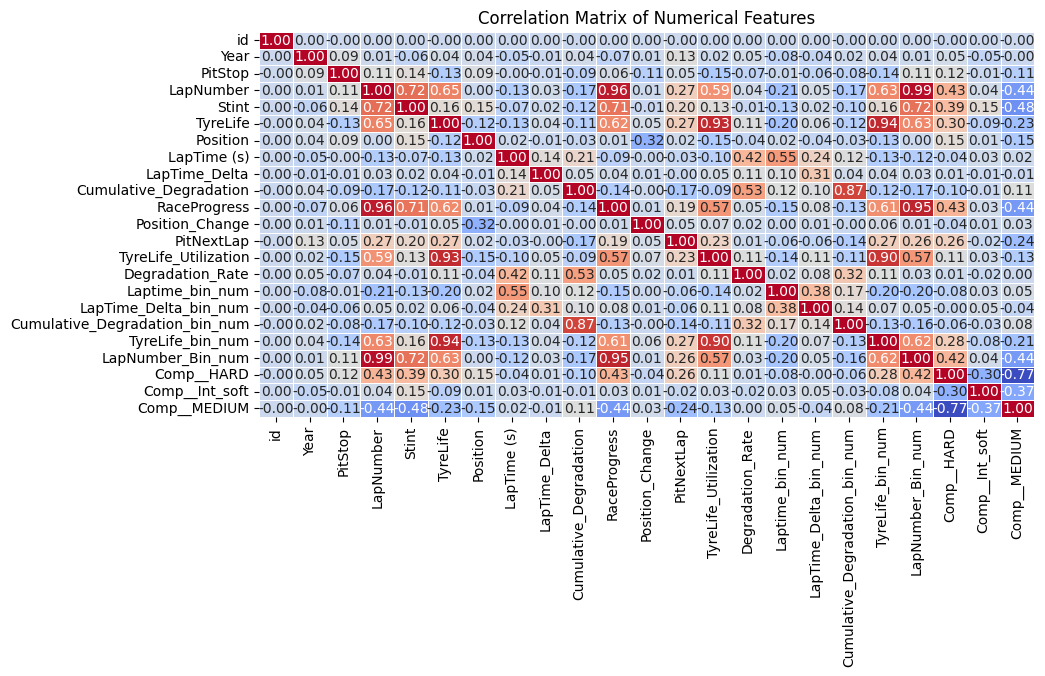

In [213]:

df_train_num = df_train.select_dtypes(include=['int', 'int8', 'float', 'float64'])
df_cr = df_train_num.corr()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_cr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=False, square=False, ax=ax)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=90, ha='center')
plt.show()

In [215]:
# Initial input features for modelling
input_features1 = ['Year', 'PitStop', 'Stint', 'TyreLife_bin_num', 'Position', 'Laptime_bin_num', 'Cumulative_Degradation_bin_num',
                    'RaceProgress', 'Position_Change', 'Comp__HARD', 'Comp__Int_soft', 'Comp__MEDIUM']
X = df_train[input_features1]
y = df_train['PitNextLap']

In [217]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.inspection import permutation_importance


In [221]:
X = df_train_num.drop(columns=['id','PitNextLap'], axis=1)
y = df_train_num['PitNextLap']
## Split the data in training and tetsing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Scale these features
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [223]:
mi = mutual_info_classif(X_train, y_train)

pd.DataFrame({
    'Feature': X.columns,
    'MI': mi
}).sort_values('MI', ascending=False)

,Feature,MI
9,RaceProgress,0.093281
3,Stint,0.087825
0,Year,0.082892
11,TyreLife_Utilization,0.077786
7,LapTime_Delta,0.064734
8,Cumulative_Degradation,0.063862
20,Comp__MEDIUM,0.060791
18,Comp__HARD,0.058617
17,LapNumber_Bin_num,0.055303
14,LapTime_Delta_bin_num,0.048670


In [224]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [225]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)

In [226]:
importance_df2 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

In [227]:
importance_df.head(10), importance_df2.head(10)

(                 Feature  Importance
 3                  Stint    0.091732
 0                   Year    0.030236
 4               TyreLife    0.018252
 11  TyreLife_Utilization    0.009725
 9           RaceProgress    0.009469
 2              LapNumber    0.005926
 7          LapTime_Delta    0.005773
 6            LapTime (s)    0.004632
 19        Comp__Int_soft    0.003672
 1                PitStop    0.003089,
                    Feature  Importance
 7            LapTime_Delta    0.105995
 0                     Year    0.082805
 3                    Stint    0.079925
 8   Cumulative_Degradation    0.068856
 6              LapTime (s)    0.068498
 11    TyreLife_Utilization    0.067077
 9             RaceProgress    0.066312
 12        Degradation_Rate    0.064601
 4                 TyreLife    0.061619
 2                LapNumber    0.061607)